# Neural Receiver for OFDM SIMO Systems

## GPU Configuration and Imports <a class="anchor" id="GPU-Configuration-and-Imports"></a>

In [1]:
import os
import tensorflow as tf
import sys
import gc
print(sys.version)
print(sys.executable)
print(sys.version_info)

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0" # 0,1,2,3
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
gpus = tf.config.list_physical_devices('GPU')

print(gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("Error loading GPU:", e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

2026-05-19 14:07:09.756114: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-19 14:07:10.155880: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-19 14:07:10.155983: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-19 14:07:10.217205: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-19 14:07:10.340072: I tensorflow/core/platform/cpu_feature_guar

3.10.12 (main, Jan 26 2026, 14:55:28) [GCC 11.4.0]
/bin/python3
sys.version_info(major=3, minor=10, micro=12, releaselevel='final', serial=0)
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-05-19 14:07:13.159498: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-19 14:07:13.495116: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-19 14:07:13.495217: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
# Import Sionna
try:
    import sionna
except ImportError as e:
    # Install Sionna if package is not already installed
    import os
    os.system("pip install sionna")
    import sionna

sionna.phy.config.seed = 42 # Set seed for reproducible random number generation

2026-05-19 14:07:14.192530: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-19 14:07:14.192647: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-19 14:07:14.192677: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-19 14:07:14.367019: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-19 14:07:14.367094: I external/local_xla/xla/stream_executor

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pickle

from tensorflow.keras import Model
from tensorflow.keras.layers import Layer, Conv2D, LayerNormalization, Dense, ReLU, Reshape, Conv2DTranspose, LeakyReLU, Flatten, Embedding
from tensorflow.nn import relu
from tensorflow.keras.models import Sequential

from sionna.phy.channel.tr38901 import Antenna, AntennaArray, CDL
from sionna.phy.channel import OFDMChannel, RayleighBlockFading, GenerateOFDMChannel
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, LinearInterpolator, RemoveNulledSubcarriers, ResourceGridDemapper, LMMSEInterpolator, BaseChannelEstimator, BaseChannelInterpolator
from sionna.phy.utils import ebnodb2no, insert_dims, flatten_last_dims, log10, expand_to_rank, split_dim
from sionna.phy.fec.ldpc.encoding import LDPC5GEncoder
from sionna.phy.fec.ldpc.decoding import LDPC5GDecoder
from sionna.phy.mapping import BinarySource, Mapper, Demapper, Constellation
from sionna.phy.utils.metrics import compute_ber
from sionna.phy.utils import sim_ber, hard_decisions

from tqdm.auto import tqdm

## Simulation Parameters <a class="anchor" id="Simulation-Parameters"></a>

In [4]:
# ## Channel configuration
carrier_frequency = 3.5e9 # Hz
cdl_model = "C" # CDL model to use
delay_spread = 100e-9 # s, Bc=1.59 MHz
speed = 10.0 # Speed for evaluation and training [m/s], Tc=4.3ms

# Ultra-high coherence channel
# delay_spread = 10e-9  # 10 ns → Bc ≈ 16 MHz
# speed = 0.1  # 0.1 m/s → Tc ≈ 428 ms

# SNR range for evaluation and training [dB]
ebno_db_min = 0.0
ebno_db_max = 15.0

############################################
## OFDM waveform configuration
subcarrier_spacing = 30e3 # Hz
fft_size = 128 # Number of subcarriers forming the resource grid, including the null-subcarrier and the guard bands
num_ofdm_symbols = 14 # Number of OFDM symbols forming the resource grid
dc_null = True # Null the DC subcarrier
num_guard_carriers = [5, 6] # Number of guard carriers on each side
pilot_pattern = "kronecker" # Pilot pattern
pilot_ofdm_symbol_indices = [2, 11] # Index of OFDM symbols carrying pilots
cyclic_prefix_length = 0 # Simulation in frequency domain. This is useless

############################################
## Modulation and coding configuration
num_bits_per_symbol = 6 # 64-QAM
coderate = 0.5 # 0.5 # Coderate for LDPC code
noise_dim = 100

############################################
## Neural receiver configuration
num_conv_channels = 128 # Number of convolutional channels for the convolutional layers forming the neural receiver
GAN_DIM=64

############################################
## Training configuration
num_training_iterations = 30000 # Number of training iterations
batch_size = 128 # Training batch size
training_batch_size = 32

The `StreamManagement` class is used to configure the receiver-transmitter association and the number of streams per transmitter.
A SIMO system is considered, with a single transmitter equipped with a single non-polarized antenna.
Therefore, there is only a single stream, and the receiver-transmitter association matrix is $[1]$.
The receiver is equipped with an antenna array.

In [5]:
stream_manager = StreamManagement(np.array([[1]]), # Receiver-transmitter association matrix
                                  1)               # One stream per transmitter

The `ResourceGrid` class is used to configure the OFDM resource grid. It is initialized with the parameters defined above.

In [6]:
resource_grid = ResourceGrid(num_ofdm_symbols = num_ofdm_symbols,
                             fft_size = fft_size,
                             subcarrier_spacing = subcarrier_spacing,
                             num_tx = 1,
                             num_streams_per_tx = 1,
                             cyclic_prefix_length = cyclic_prefix_length,
                             dc_null = dc_null,
                             pilot_pattern = pilot_pattern,
                             pilot_ofdm_symbol_indices = pilot_ofdm_symbol_indices,
                             num_guard_carriers = num_guard_carriers)

2026-05-19 14:07:15.078425: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Outer coding is performed such that all the databits carried by the resource grid with size `fft_size`x`num_ofdm_symbols` form a single codeword.

In [7]:
MOD_ORDERS      = [2, 4, 6]          # QPSK, 16QAM, 64QAM → bits per symbol
MOD_IDX_MAP     = {2: 0, 4: 1, 6: 2} # for FiLM embedding lookup
max_bits_per_symbol = 6
# Pre-compute (k, n) per modulation
def compute_kn(nbps):
    n_ = int(resource_grid.num_data_symbols * nbps)
    k_ = int(n_ * coderate)
    return k_, n_
KN_TABLE = {nbps: compute_kn(nbps) for nbps in MOD_ORDERS}
print(KN_TABLE)

{2: (1392, 2784), 4: (2784, 5568), 6: (4176, 8352)}


In [8]:
# Codeword length. It is calculated from the total number of databits carried by the resource grid, and the number of bits transmitted per resource element
n = int(resource_grid.num_data_symbols*num_bits_per_symbol)
# Number of information bits per codeword
k = int(n*coderate)

print(n, k)

8352 4176


The SIMO link is setup by considering an uplink transmission with one user terminal (UT) equipped with a single non-polarized antenna, and a base station (BS) equipped with an antenna array.
One can try other configurations for the BS antenna array.

In [9]:
ut_antenna = Antenna(polarization="single",
                     polarization_type="V",
                     antenna_pattern="38.901",
                     carrier_frequency=carrier_frequency)

# bs_array = AntennaArray(num_rows=1,
#                         num_cols=1,
#                         polarization="dual",
#                         polarization_type="VH",
#                         antenna_pattern="38.901",
#                         carrier_frequency=carrier_frequency)

bs_array = AntennaArray(num_rows=1,
                        num_cols=1,
                        polarization="single", # dual
                        polarization_type="V", # VH
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)

## New Neural Receiver

In [16]:
class ResidualBlock(Layer):
    r"""
    Input
    ------
    : [batch size, num time samples, num subcarriers, num_conv_channel], tf.float
        Input of the layer
    Output
    -------
    : [batch size, num time samples, num subcarriers, num_conv_channel], tf.float
        Output of the layer
    """

    def __init__(self, kernel_size=[3,3], **kwargs):
        super().__init__(**kwargs)
        self._kernel_size = kernel_size
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_1 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_1 = Conv2D(filters=num_conv_channels,
                              kernel_size=self._kernel_size,
                              padding='same',
                              activation=None)
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_2 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_2 = Conv2D(filters=num_conv_channels,
                              kernel_size=self._kernel_size,
                              padding='same',
                              activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._conv_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._conv_2(z) # [batch size, num time samples, num subcarriers, num_channels]
        # Skip connection
        z = z + inputs

        return z

In [22]:
class NR_NN1(Model):
    """
        y_pilot, x_pilot, no                      [batch, 2, fft_size], [batch]
            ↓  stack real/imag + tile no          [batch, 2, fft_size, 5]
            ↓  input Conv2D [1,3]  (freq only)
            ↓  ResBlock [1,3]*2                 ← denoise along frequency
                                                  [batch, 2, fft_size, C]
            ↓  Dense(2 → 14) along time axis      ← learned interpolation
                                                  [batch, 14, fft_size, C]
        Output: H_feature

    Input
    -----
    y_pilot : [batch, 2, fft_size], tf.complex64
    x_pilot : [batch, 2, fft_size], tf.complex64
    no      : [batch], tf.float32

    Output
    ------
    H_feature : [batch, 14, fft_size, num_conv_channels], tf.float32
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Input convolution (frequency only, 1x3)
        self._input_conv = Conv2D(filters=num_conv_channels,
                                kernel_size=[1,3],
                                padding='same',
                                activation=None)
        
        # Residual blocks for frequency denoising
        self._res_block_freq_1 = ResidualBlock(kernel_size=[1,3])
        self._res_block_freq_2 = ResidualBlock(kernel_size=[1,3])

        # interpolation from 2 pilot symbols to 14 OFDM symbols
        self._interp_dense = Dense(14, activation=None)

    def call(self, y_pilot, x_pilot, no):
        # Feeding the noise power in log10 scale helps with the performance
        no = log10(no)
        no = insert_dims(no, 3, 1)  # [batch, 1, 1, 1]
        no = tf.tile(no, [1, 2, y_pilot.shape[-1], 1])  # [batch, 2, fft_size, 1]

        # Stack real and imaginary parts of y_pilot and x_pilot
        z = tf.stack([tf.math.real(y_pilot),
                      tf.math.imag(y_pilot),
                      tf.math.real(x_pilot),
                      tf.math.imag(x_pilot)], axis=-1)  # [batch, 2, fft_size, 4]
        
        # Concatenate noise channel
        z = tf.concat([z, no], axis=-1)  # [batch, 2, fft_size, 5]

        # Input conv (frequency only)
        z = self._input_conv(z)
        # frequency denoising
        z = self._res_block_freq_1(z)
        z = self._res_block_freq_2(z) # z : [batch, 2, 128, channel]

        # interpolation along time axis
        z = tf.transpose(z, [0, 2, 3, 1]) # [batch, 128, channel, 2]
        z = self._interp_dense(z)
        z = tf.transpose(z, [0, 3, 1, 2]) # [batch, 14, 128, channel]

        return z


class NR_NN2(Model):
    """
    Input
    -----
    H_feature : [batch, 14, fft_size, C],          tf.float32
    no        : [batch, 1],                        tf.float32
    y         : [batch, num_rx_ant, 14, fft_size], tf.complex64
    constellation_points : [M, 2],                 tf.float32

    Output
    ------
    llrs : [batch, 14, fft_size, num_bits_per_symbol], tf.float32
        LLRs at non-data positions discarded.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Input convolution
        self._input_conv = Conv2D(filters=num_conv_channels,
                                  kernel_size=[3,3],
                                  padding='same',
                                  activation=None)
        # Residual blocks
        self._res_block_1 = ResidualBlock()
        self._res_block_2 = ResidualBlock()
        self._res_block_3 = ResidualBlock()
        self._res_block_4 = ResidualBlock()
        # Output conv
        self._output_conv = Conv2D(filters=num_bits_per_symbol,
                                   kernel_size=[3,3],
                                   padding='same',
                                   activation=None)

    def call(self, H_feature, y, no, constellation_points):
        # Feeding the noise power in log10 scale helps with the performance
        no = log10(no)

        # Stacking the real and imaginary components along the 'channel' dimension
        y = tf.transpose(y, [0, 2, 3, 1]) # Putting antenna dimension last
        no = insert_dims(no, 3, 1)
        no = tf.tile(no, [1, y.shape[1], y.shape[2], 1])
        
        z = tf.concat([tf.math.real(y),
                       tf.math.imag(y),
                       no,
                       H_feature], axis=-1) # z : [batch size, 14, 128, 2*rx_ant + 1 + conv]
        
        # constellation_points [M, 2] flatten to [2*M]
        const_flat = tf.reshape(constellation_points, [-1])
        batch_size = tf.shape(z)[0] # [batch, 14, 128, 2*M]
        const_tiled = tf.tile(tf.reshape(const_flat, [1, 1, 1, -1]),
                                [batch_size, z.shape[1], z.shape[2], 1])
        z = tf.concat([z, const_tiled], axis=-1)  # [batch, 14, 128, 2*rx_ant + 1 + conv + 2*M]

        # Input conv
        z = self._input_conv(z)
        # Residual blocks
        z = self._res_block_1(z)
        z = self._res_block_2(z)
        z = self._res_block_3(z)
        z = self._res_block_4(z)
        # Output conv
        z = self._output_conv(z)

        return z


class NeuralReceiver(Model):
    """
    Keras layer implementing a residual convolutional neural receiver.

    This neural receiver is fed with the post-DFT received samples, forming a resource grid of size num_of_symbols x fft_size, and computes LLRs on the transmitted coded bits.
    These LLRs can then be fed to an outer decoder to reconstruct the information bits.

    As the neural receiver is fed with the entire resource grid, including the guard bands and pilots, it also computes LLRs for these resource elements.
    They must be discarded to only keep the LLRs corresponding to the data-carrying resource elements.

    Input
    ------
    y : [batch size, num rx antenna, num ofdm symbols, num subcarriers], tf.complex
        Received post-DFT samples.
    no : [batch size], tf.float32
        Noise variance. At training, a different noise variance value is sampled for each batch example.
    constellation_points : [M, 2], tf.float32
        Constellation from mapper (optional)

    Output
    -------
    : [batch size, num ofdm symbols, num subcarriers, num_bits_per_symbol]
        LLRs on the transmitted bits.
        LLRs computed for resource elements not carrying data (pilots, guard bands...) must be discarded.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._channel_estimation = NR_NN1()
        self._equalization = NR_NN2()

    def call(self, y, no, y_pilot, x_pilot, constellation_points):
        # NN1: Channel estimation and interpolation
        H_feature = self._channel_estimation(y_pilot, x_pilot, no)
        # NN2: Equalization and demapping
        llrs = self._equalization(H_feature, y, no, constellation_points)
        return llrs

In [18]:
NR = NeuralReceiver()
y_pilot = tf.zeros([1, 2, 128], dtype=tf.complex64)
x_pilot = tf.zeros([1, 2, 128], dtype=tf.complex64)
y = tf.zeros([1, 1, 14, 128], dtype=tf.complex64)
no = tf.zeros([1], dtype=tf.float32)
constellation_points = tf.zeros([64, 2], dtype=tf.float32)

_ = NR(y, no, y_pilot, x_pilot, constellation_points=constellation_points)
NR._channel_estimation.summary()
NR._equalization.summary()

2026-02-27 11:57:20.881924: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-02-27 11:57:21.170470: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Model: "nr_nn1_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          multiple                  2048      
                                                                 
 residual_block_6 (Residual  multiple                  229632    
 Block)                                                          
                                                                 
 residual_block_7 (Residual  multiple                  229632    
 Block)                                                          
                                                                 
 dense_1 (Dense)             multiple                  42        
                                                                 
Total params: 461354 (1.76 MB)
Trainable params: 461354 (1.76 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "nr_nn2_1"
____

### Modulation-agnostic NR (FiLM)

In [76]:
class ResidualBlock(Layer):
    def __init__(self, kernel_size=[3,3], **kwargs):
        super().__init__(**kwargs)
        self._layer_norm_1 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_1 = Conv2D(filters=num_conv_channels, kernel_size=kernel_size, padding='same', activation=None)
        self._layer_norm_2 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_2 = Conv2D(filters=num_conv_channels, kernel_size=kernel_size, padding='same', activation=None)
        self._film = Dense(2 * num_conv_channels, activation=None)

    def call(self, inputs, cond):
        gamma, beta = tf.split(self._film(cond), 2, axis=-1)
        gamma = insert_dims(gamma, 2, 1)  # [batch, 1, 1, C]
        beta  = insert_dims(beta,  2, 1)

        z = self._layer_norm_1(inputs)
        z = gamma * z + beta
        z = relu(z)
        z = self._conv_1(z)

        z = self._layer_norm_2(z)
        z = gamma * z + beta
        z = relu(z)
        z = self._conv_2(z)

        return z + inputs

class FiLMConditioner(Layer):
    def __init__(self, num_mod_orders=3, **kwargs):
        super().__init__(**kwargs)
        self._mod_embedding = Embedding(num_mod_orders, 16)  # 0=QPSK, 1=16QAM, 2=64QAM

    def call(self, mcs_idx, no_log):
        mod_emb = self._mod_embedding(mcs_idx) # [batch, 16]
        return tf.concat([mod_emb, no_log[:, None]], axis=-1) # [batch, 17]

In [77]:
class NR_NN1(Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._input_conv = Conv2D(filters=num_conv_channels, kernel_size=[1,3], padding='same', activation=None)
        self._res_block_freq_1 = ResidualBlock(kernel_size=[1,3])
        self._res_block_freq_2 = ResidualBlock(kernel_size=[1,3])
        self._interp_dense = Dense(14, activation=None)

    def call(self, y_pilot, x_pilot, no_log, cond):
        # no_log already log10-scaled
        no = insert_dims(no_log, 3, 1)
        no = tf.tile(no, [1, 2, y_pilot.shape[-1], 1]) # [batch, 2, fft_size, 1]

        z = tf.stack([tf.math.real(y_pilot),
                      tf.math.imag(y_pilot),
                      tf.math.real(x_pilot),
                      tf.math.imag(x_pilot)], axis=-1) # [batch, 2, fft_size, 4]
        z = tf.concat([z, no], axis=-1) # [batch, 2, fft_size, 5]

        z = self._input_conv(z)
        z = self._res_block_freq_1(z, cond)
        z = self._res_block_freq_2(z, cond) # [batch, 2, fft_size, C]

        z = tf.transpose(z, [0, 2, 3, 1]) # [batch, fft_size, C, 2]
        z = self._interp_dense(z)
        z = tf.transpose(z, [0, 3, 1, 2]) # [batch, 14, fft_size, C]
        return z


class NR_NN2(Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._input_conv = Conv2D(filters=num_conv_channels, kernel_size=[3,3], padding='same', activation=None)
        self._res_block_1 = ResidualBlock()
        self._res_block_2 = ResidualBlock()
        self._res_block_3 = ResidualBlock()
        self._res_block_4 = ResidualBlock()
        self._output_conv = Conv2D(filters=num_bits_per_symbol, kernel_size=[3,3], padding='same', activation=None)

    def call(self, H_feature, y, no_log, cond):
        y = tf.transpose(y, [0, 2, 3, 1]) # [batch, 14, fft_size, rx_ant]

        no = insert_dims(no_log, 3, 1)
        no = tf.tile(no, [1, y.shape[1], y.shape[2], 1]) # [batch, 14, fft_size, 1]

        z = tf.concat([tf.math.real(y), tf.math.imag(y), no, H_feature], axis=-1)

        z = self._input_conv(z)
        z = self._res_block_1(z, cond)
        z = self._res_block_2(z, cond)
        z = self._res_block_3(z, cond)
        z = self._res_block_4(z, cond)
        z = self._output_conv(z)
        return z


class NeuralReceiver(Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._conditioner = FiLMConditioner()
        self._channel_estimation = NR_NN1()
        self._equalization = NR_NN2()

    def call(self, y, no, y_pilot, x_pilot, mcs_idx):
        no_log = log10(no) # log10 here for easier computation
        cond = self._conditioner(mcs_idx, no_log) # [batch, 17]

        H_feature = self._channel_estimation(y_pilot, x_pilot, no_log, cond)
        llrs = self._equalization(H_feature, y, no_log, cond)
        return llrs

In [78]:
NR = NeuralReceiver()

y_pilot = tf.zeros([1, 2, 128], dtype=tf.complex64)
x_pilot = tf.zeros([1, 2, 128], dtype=tf.complex64)
y = tf.zeros([1, 1, 14, 128], dtype=tf.complex64)
no = tf.ones([1], dtype=tf.float32)
mcs_idx = tf.zeros([1], dtype=tf.int32)

_ = NR(y, no, y_pilot, x_pilot, mcs_idx)

NR._channel_estimation.summary()
NR._equalization.summary()

Model: "nr_nn1_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_210 (Conv2D)         multiple                  2048      
                                                                 
 residual_block_84 (Residua  multiple                  234240    
 lBlock)                                                         
                                                                 
 residual_block_85 (Residua  multiple                  234240    
 lBlock)                                                         
                                                                 
 dense_34 (Dense)            multiple                  42        
                                                                 
Total params: 470570 (1.80 MB)
Trainable params: 470570 (1.80 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Model: "nr_nn2_14"
__

## End-to-end System <a class="anchor" id="End-to-end-System"></a>

### MLP-mapper

In [20]:
class SNRNFMapper(Layer):
    def __init__(self,
                 num_bits_per_symbol,
                 **kwargs):
        super().__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.num_constellation_points = 2 ** num_bits_per_symbol
        
        # Base QAM constellation
        qam_points = Constellation("qam", num_bits_per_symbol).points
        
        # Trainable base constellation using tf.Variable
        self.base_points_r = tf.Variable(
            initial_value=tf.math.real(qam_points),
            trainable=True,
            dtype=tf.float32,
            name='base_points_r'
        )
        self.base_points_i = tf.Variable(
            initial_value=tf.math.imag(qam_points),
            trainable=True,
            dtype=tf.float32,
            name='base_points_i'
        )
        
        # SNR embedding network (generates constellation adjustments)
        self.snr_dense1 = Dense(256, activation='relu', name='snr_embed1')
        self.constellation_I_dense = Dense(self.num_constellation_points, name='constellation_I')
        self.constellation_Q_dense = Dense(self.num_constellation_points, name='constellation_Q')
        
        # Bit positions for mapping
        n = num_bits_per_symbol
        self._bit_positions = tf.cast(tf.range(n-1, -1, -1), dtype=tf.int32)
    
    def call(self, bits, ebno_db, training=False):
        """
        Args:
            bits: [..., num_bits] binary tensor
            ebno_db: scalar or [...] - SNR in dB
        Returns:
            x_real: [..., num_symbols, 2] where last dim is [I, Q]
            constellation_points: [M] complex - for visualization
        """
        batch_size = tf.shape(bits)[0]
        
        # Process SNR through embedding network
        ebno_db_expanded = tf.reshape(ebno_db, [batch_size, 1])
        ebno_db_expanded = tf.cast(ebno_db_expanded, tf.float32)
        
        x = self.snr_dense1(ebno_db_expanded, training=training)
        
        points_r = self.constellation_I_dense(x, training=training)  # [batch, M]
        points_i = self.constellation_Q_dense(x, training=training)  # [batch, M]
        
        # Aggregate to single constellation (non-batched)
        points_r = tf.reduce_mean(points_r, axis=0)  # [M]
        points_i = tf.reduce_mean(points_i, axis=0)  # [M]
        
        # Normalize to unit average energy
        point_energy = points_r**2 + points_i**2
        avg_energy = tf.reduce_mean(point_energy)
        norm_factor = tf.sqrt(avg_energy)
        points_r = points_r / norm_factor
        points_i = points_i / norm_factor
        
        # Convert bits to indices
        bits = tf.cast(bits, dtype=tf.int32)
        n1 = int(bits.shape[-1] / self.num_bits_per_symbol)
        new_shape = [n1, self.num_bits_per_symbol]
        bits = split_dim(bits, new_shape, axis=tf.rank(bits)-1)
        
        shifted_bits = tf.bitwise.left_shift(bits, self._bit_positions)
        int_rep = tf.reduce_sum(shifted_bits, axis=-1)
        
        # Map bits to constellation (non-batched, so axis=0)
        x_I = tf.gather(points_r, int_rep, axis=0)
        x_Q = tf.gather(points_i, int_rep, axis=0)
        
        constellation_points = tf.complex(points_r, points_i)  # for checking
        
        x_real = tf.stack([x_I, x_Q], axis=-1)
        
        return x_real, constellation_points

### Res-mapper

In [ ]:
class ResidualBlock1D(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._layer_norm_1 = LayerNormalization(axis=-1)
        self._dense_1 = Dense(256, activation=None)
        self._layer_norm_2 = LayerNormalization(axis=-1)
        self._dense_2 = Dense(256, activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._dense_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._dense_2(z)
        # Skip connection
        z = z + inputs
        return z

class SNRNFMapper(Layer):
    def __init__(self, num_bits_per_symbol, **kwargs):
        super().__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.num_constellation_points = 2 ** num_bits_per_symbol
        
        # SNR embedding network with ResNet
        self._input_dense = Dense(256, activation=None, name='snr_input')
        self._res_blocks = [ResidualBlock1D(name=f'res_block_{i}') for i in range(3)]
        self._output_dense_I = Dense(self.num_constellation_points, name='constellation_I')
        self._output_dense_Q = Dense(self.num_constellation_points, name='constellation_Q')
        
        # mapping bit positions
        n = num_bits_per_symbol
        self._bit_positions = tf.cast(tf.range(n-1, -1, -1), dtype=tf.int32)
    
    def call(self, bits, ebno_db, training=False):
        """
        Args:
            bits: [..., num_bits] binary tensor
            ebno_db: scalar or [...] - SNR in dB
        Returns:
            x_real: [..., num_symbols, 2] where last dim is [I, Q]
            constellation_points: [M] complex - for visualization
        """
        batch_size = tf.shape(bits)[0]
        
        # Process SNR through ResNet
        ebno_db_expanded = tf.reshape(ebno_db, [batch_size, 1])
        ebno_db_expanded = tf.cast(ebno_db_expanded, tf.float32)
        
        z = self._input_dense(ebno_db_expanded, training=training)
        for res_block in self._res_blocks:
            z = res_block(z)
        
        points_r = self._output_dense_I(z, training=training)  # [batch, M]
        points_i = self._output_dense_Q(z, training=training)  # [batch, M]
        
        # Aggregate to single constellation (non-batched)
        points_r = tf.reduce_mean(points_r, axis=0)  # [M]
        points_i = tf.reduce_mean(points_i, axis=0)  # [M]
        
        # Normalize to unit average energy
        point_energy = points_r**2 + points_i**2
        avg_energy = tf.reduce_mean(point_energy)
        norm_factor = tf.sqrt(avg_energy)
        points_r = points_r / norm_factor
        points_i = points_i / norm_factor
        
        # Convert bits to indices
        bits = tf.cast(bits, dtype=tf.int32)
        n1 = int(bits.shape[-1] / self.num_bits_per_symbol)
        new_shape = [n1, self.num_bits_per_symbol]
        bits = split_dim(bits, new_shape, axis=tf.rank(bits)-1)
        
        shifted_bits = tf.bitwise.left_shift(bits, self._bit_positions)
        int_rep = tf.reduce_sum(shifted_bits, axis=-1)
        
        # Map bits to constellation (non-batched, so axis=0)
        x_I = tf.gather(points_r, int_rep, axis=0)
        x_Q = tf.gather(points_i, int_rep, axis=0)
        
        constellation_points = tf.complex(points_r, points_i)
        
        x_real = tf.stack([x_I, x_Q], axis=-1)
        
        return x_real, constellation_points

### FiLM-mapper

In [ ]:
class ResidualBlock1D(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._layer_norm_1 = LayerNormalization(axis=-1)
        self._dense_1 = Dense(256, activation=None)
        self._layer_norm_2 = LayerNormalization(axis=-1)
        self._dense_2 = Dense(256, activation=None)
        self._film = Dense(2 * 256, activation=None)

    def call(self, inputs, cond):
        gamma, beta = tf.split(self._film(cond), 2, axis=-1)  # [batch, 256] each

        z = self._layer_norm_1(inputs)
        z = gamma * z + beta
        z = relu(z)
        z = self._dense_1(z)

        z = self._layer_norm_2(z)
        z = gamma * z + beta
        z = relu(z)
        z = self._dense_2(z)

        return z + inputs


class ResSNRFiLMMapper(Layer):
    def __init__(self, max_bits_per_symbol=6, num_mod_orders=3, **kwargs):
        """
        max_bits_per_symbol: largest M used (e.g. 6 for 64QAM)
        num_mod_orders:      number of modulation orders (e.g. 3 for QPSK/16QAM/64QAM)
        """
        super().__init__(**kwargs)
        self.max_bits_per_symbol = max_bits_per_symbol
        self.max_constellation_points = 2 ** max_bits_per_symbol # 6=64

        # conditioning: mod order embedding + SNR
        self._mod_embedding = Embedding(num_mod_orders, 16)  # 0=QPSK, 1=16QAM, 2=64QAM
        self._cond_dense = Dense(256, activation=None, name='cond_input')

        # ResNet trunk
        self._input_dense = Dense(256, activation=None, name='snr_input')
        self._res_blocks = [ResidualBlock1D(name=f'res_block_{i}') for i in range(3)]

        self._output_dense_I = Dense(self.max_constellation_points, name='constellation_I')
        self._output_dense_Q = Dense(self.max_constellation_points, name='constellation_Q')

    def call(self, bits, ebno_db, mcs_idx, num_bits_per_symbol, training=False):
        """
        Args:
            bits:                [..., num_bits] binary tensor
            ebno_db:             [batch] or scalar
            mcs_idx:             [batch] int - 0=QPSK, 1=16QAM, 2=64QAM
            num_bits_per_symbol: scalar int - actual M for this batch
        Returns:
            x_real:              [..., num_symbols, 2] where last dim is [I, Q]
            constellation_points:[M] complex - for visualization
        """
        batch_size = tf.shape(bits)[0]
        num_constellation_points = 2 ** num_bits_per_symbol

        # prepare conditioning
        ebno = tf.reshape(tf.cast(ebno_db, tf.float32), [batch_size, 1])
        mod_emb = self._mod_embedding(mcs_idx) # [batch, 16]
        cond_raw = tf.concat([ebno, mod_emb], axis=-1) # [batch, 17]
        cond = self._cond_dense(cond_raw) # [batch, 256]

        z = self._input_dense(ebno, training=training) # input SNR
        for res_block in self._res_blocks:
            z = res_block(z, cond) # FiLM conditioning

        points_r = self._output_dense_I(z, training=training) # [batch, 64]
        points_i = self._output_dense_Q(z, training=training) # [batch, 64]

        # slice to actual constellation size
        points_r = points_r[:, :num_constellation_points] # [batch, M]
        points_i = points_i[:, :num_constellation_points] # [batch, M]

        # normalize
        points_r = tf.reduce_mean(points_r, axis=0) # [M]
        points_i = tf.reduce_mean(points_i, axis=0) # [M]
        avg_energy = tf.reduce_mean(points_r**2 + points_i**2)
        norm_factor = tf.sqrt(avg_energy)
        points_r = points_r / norm_factor
        points_i = points_i / norm_factor

        bit_positions = tf.cast(tf.range(num_bits_per_symbol - 1, -1, -1), dtype=tf.int32)
        bits = tf.cast(bits, dtype=tf.int32)
        n1 = int(bits.shape[-1] / num_bits_per_symbol)
        bits = split_dim(bits, [n1, num_bits_per_symbol], axis=tf.rank(bits) - 1)
        int_rep = tf.reduce_sum(tf.bitwise.left_shift(bits, bit_positions), axis=-1)

        x_I = tf.gather(points_r, int_rep, axis=0)
        x_Q = tf.gather(points_i, int_rep, axis=0)

        constellation_points = tf.complex(points_r, points_i)
        x_real = tf.stack([x_I, x_Q], axis=-1)

        return x_real, constellation_points

In [32]:
## Transmitter
binary_source = BinarySource()
qam_mapper = Mapper("qam", num_bits_per_symbol)
mapper = SNRNFMapper(num_bits_per_symbol=num_bits_per_symbol)
rg_mapper = ResourceGridMapper(resource_grid)

## Channel
cdl = CDL(cdl_model, delay_spread, carrier_frequency,
          ut_antenna, bs_array, "uplink", min_speed=speed)
channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

## Receiver
neural_receiver = NeuralReceiver()
rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements

The following cell performs one forward step through the end-to-end system:

In [ ]:
batch_size = 128
ebno_db = tf.fill([batch_size], 5.0)
no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)

## Transmitter
# Generate codewords
c = binary_source([batch_size, 1, 1, n])
print("c shape: ", c.shape)

## First stage
x_init = qam_mapper(c)
x_rg_init = rg_mapper(x_init)

# Map bits to QAM symbols
x, constellation_points = mapper(c, ebno_db, training=True)
print("x shape: ", x.shape, x.dtype)
print("constellation shape: ", constellation_points.shape, constellation_points.dtype)
# Map the QAM symbols to a resource grid
x = tf.complex(x[...,0], x[...,1])
x_rg = rg_mapper(x)
print("x_rg shape: ", x_rg.shape, x_rg.dtype)

######################################
## Channel
# A batch of new channel realizations is sampled and applied at every inference
no_ = expand_to_rank(no, tf.rank(x_rg))
y,_ = channel(x_rg, no_)
print("y shape: ", y.shape)

######################################
## Receiver
# The neural receiver computes LLRs from the frequency domain received symbols and N0
y = tf.squeeze(y, axis=1)
llr = neural_receiver(y, no)
print("llr shape: ", llr.shape)
# Reshape the input to fit what the resource grid demapper is expected
llr = insert_dims(llr, 2, 1)
# Extract data-carrying resource elements. The other LLRs are discarded
llr = rg_demapper(llr)
llr = tf.reshape(llr, [batch_size, 1, 1, n])
print("Post RG-demapper LLRs: ", llr.shape)

The BMD rate is computed from the LLRs and transmitted bits as follows:

In [ ]:
bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
bce = tf.reduce_mean(bce)
rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
print(f"Rate: {rate:.2E} bit")

Rate: -6.97E-01 bit


The rate is very poor (negative values means 0 bit) as the neural receiver is not trained.

## End-to-end System as a Sionna Block

In [34]:
class E2ESystem(Model):
    def __init__(self, system, training=False, use_fec=True):
        super().__init__()
        self._system = system
        self._training = training
        self._use_fec = use_fec

        ######################################
        ## Transmitter
        self._binary_source = BinarySource()
        
        if not training and use_fec:
            self._encoder = LDPC5GEncoder(k, n)
            self._decoder = LDPC5GDecoder(self._encoder, cn_update='offset-minsum', hard_out=True)
        
        # qam
        # self._mapper = Mapper("qam", num_bits_per_symbol)
        
        # non-frame
        self._mapper = SNRNFMapper(num_bits_per_symbol=num_bits_per_symbol)

        self._rg_mapper = ResourceGridMapper(resource_grid)

        ######################################
        ## Channel
        # A 3GPP CDL channel model is used
        cdl = CDL(cdl_model, delay_spread, carrier_frequency,
                  ut_antenna, bs_array, "uplink", min_speed=speed, max_speed=speed)
        self._channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

        ######################################
        ## Receiver
        # Three options for the receiver depending on the value of `system`
        if "baseline" in system:
            self._removed_null_subc = RemoveNulledSubcarriers(resource_grid)
            self.interpolator = LinearInterpolator(resource_grid.pilot_pattern)
            self._ls_est = LSChannelEstimator(resource_grid, interpolator=self.interpolator)
            # Components required by both baselines
            self._lmmse_equ = LMMSEEqualizer(resource_grid, stream_manager, )
            self._demapper = Demapper("app", "qam", num_bits_per_symbol)
            
        elif system == "neural-receiver": # Neural receiver
            self._neural_receiver = NeuralReceiver()
            self._rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements      


    @tf.function
    def call(self, batch_size, ebno_db):

        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created as it is what is expected by some layers
        if len(ebno_db.shape) == 0:
            ebno_db = tf.fill([batch_size], ebno_db)

        ######################################
        ## Transmitter
        if self._use_fec:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        else:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, 1.0)
        # Outer coding is only performed if not training and FEC is enabled
        if self._training or not self._use_fec:
            c = self._binary_source([batch_size, 1, 1, n])
            b = c
        else:
            b = self._binary_source([batch_size, 1, 1, k])
            c = self._encoder(b)
        
        # x = self._mapper(c)
        
        # Frame or NF
        x, constellation_points = self._mapper(c, ebno_db, training=self._training)
        self.constellation_points = constellation_points
        constellation_points = tf.stack([tf.math.real(constellation_points),
                                    tf.math.imag(constellation_points)], axis=-1)

        x = tf.complex(x[...,0], x[...,1])
        
        x_rg = self._rg_mapper(x)

        ######################################
        ## Channel
        # A batch of new channel realizations is sampled and applied at every inference
        no_ = expand_to_rank(no, tf.rank(x_rg))
        y,h = self._channel(x_rg, no_)

        # Manual AWGN: h = 1 everywhere
        # h = tf.ones_like(h, dtype=h.dtype)
        # y = x_rg  # No channel distortion
        # Add AWGN noise
        # noise_real = tf.random.normal(tf.shape(y), 
        #                                 stddev=tf.sqrt(no_/2),
        #                                 dtype=y.dtype.real_dtype)
        # noise_imag = tf.random.normal(tf.shape(y), 
        #                                 stddev=tf.sqrt(no_/2),
        #                                 dtype=y.dtype.real_dtype)
        # noise = tf.complex(noise_real, noise_imag)
        # y = y + noise
        
        ######################################
        ## Receiver
        # Three options for the receiver depending on the value of ``system``
        if "baseline" in self._system:
            # debugging
            h_perfect = self._removed_null_subc(h)
            h_ls, err_var = self._ls_est(y, no)

            if self._system == 'baseline-perfect-csi':
                h_hat = self._removed_null_subc(h) # Extract non-null subcarriers
                err_var = 0.0 # No channel estimation error when perfect CSI knowledge is assumed
            elif self._system == 'baseline-ls-estimation':
                h_hat, err_var = self._ls_est(y, no) # LS channel estimation with nearest-neighbor
                err_var = 0.0
                
            x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no) # LMMSE equalization
            no_eff_= expand_to_rank(no_eff, tf.rank(x_hat))
            llr = self._demapper(x_hat, no_eff_) # Demapping

        elif self._system == "neural-receiver":
            # Extract pilot symbols from received signal and transmitted pilots
            y_pilot = tf.gather(y[:, 0, 0, :, :], pilot_ofdm_symbol_indices, axis=1)  # [batch, 2, fft_size]
            x_pilot = tf.gather(x_rg[:, 0, 0, :, :], pilot_ofdm_symbol_indices, axis=1)  # [batch, 2, fft_size]

            # The neural receiver computes LLRs from the frequency domain received symbols and N0
            y = tf.squeeze(y, axis=2)  # [batch, 1, 14, fft_size] - keep num_rx_ant dim
            llr = self._neural_receiver(y, no, y_pilot, x_pilot, constellation_points)

            llr = insert_dims(llr, 2, 1) # Reshape the input to fit what the resource grid demapper is expected
            llr = self._rg_demapper(llr) # Extract data-carrying resource elements. The other LLrs are discarded
            llr = tf.reshape(llr, [batch_size, 1, 1, n]) # Reshape the LLRs to fit what the outer decoder is expected

        
        # Outer coding is not needed if the information rate is returned or FEC is disabled
        if self._training:
            # Use the transmitted bits (c) for comparison
            bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
            bce = tf.reduce_mean(bce)
            rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
            return rate
        else:
            if self._use_fec:
                b_hat = self._decoder(llr)
            else:
                # Hard decision on LLRs without FEC
                b_hat = tf.cast(tf.greater(llr, 0.0), dtype=b.dtype)
            return b, b_hat # Ground truth and reconstructed information bits returned for BER/BLER computation

### FiLM

In [ ]:
class E2ESystem(Model):
    def __init__(self, system, training=False, use_fec=True):
        super().__init__()
        self._system = system
        self._training = training
        self._use_fec = use_fec

        ######################################
        ## Transmitter
        self._binary_source = BinarySource()
        
        if not training and use_fec:
            # self._encoder = LDPC5GEncoder(k, n)
            self._encoders  = {nbps: LDPC5GEncoder(KN_TABLE[nbps][0], KN_TABLE[nbps][1])
                                for nbps in MOD_ORDERS}
            self._decoders  = {nbps: LDPC5GDecoder(self._encoders[nbps], cn_update='offset-minsum', hard_out=True)
                                for nbps in MOD_ORDERS}
            # self._decoder = LDPC5GDecoder(self._encoder, cn_update='offset-minsum', hard_out=True)
        
        # qam
        # self._mapper = Mapper("qam", num_bits_per_symbol)
        self._mappers = {nbps: Mapper("qam", nbps) for nbps in MOD_ORDERS}
        
        # non-frame
        # self._mapper = SNRNFMapper(num_bits_per_symbol=num_bits_per_symbol)

        self._rg_mapper = ResourceGridMapper(resource_grid)

        ######################################
        ## Channel
        # A 3GPP CDL channel model is used
        cdl = CDL(cdl_model, delay_spread, carrier_frequency,
                  ut_antenna, bs_array, "uplink", min_speed=speed, max_speed=speed)
        self._channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

        ######################################
        ## Receiver
        # Three options for the receiver depending on the value of `system`
        if "baseline" in system:
            self._removed_null_subc = RemoveNulledSubcarriers(resource_grid)
            self.interpolator = LinearInterpolator(resource_grid.pilot_pattern)
            self._ls_est = LSChannelEstimator(resource_grid, interpolator=self.interpolator)
            # Components required by both baselines
            self._lmmse_equ = LMMSEEqualizer(resource_grid, stream_manager, )
            # self._demapper = Demapper("app", "qam", num_bits_per_symbol)
            self._demappers = {nbps: Demapper("app", "qam", nbps) for nbps in MOD_ORDERS}
            
        elif system == "neural-receiver": # Neural receiver
            self._neural_receiver = NeuralReceiver()
            self._rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements      


    @tf.function
    def call(self, batch_size, ebno_db, nbps):

        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created as it is what is expected by some layers
        if len(ebno_db.shape) == 0:
            ebno_db = tf.fill([batch_size], ebno_db)
        
        k, n = KN_TABLE[nbps]
        mod_idx = tf.fill([batch_size],
                          tf.constant(MOD_IDX_MAP[nbps], dtype=tf.int32))

        ######################################
        ## Transmitter
        if self._use_fec:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        else:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, 1.0)
        # Outer coding is only performed if not training and FEC is enabled
        if self._training or not self._use_fec:
            c = self._binary_source([batch_size, 1, 1, n]).
            b = c
        else:
            b = self._binary_source([batch_size, 1, 1, k])
            c = self._encoders[nbps](b)
        
        # x = self._mapper(c)
        x = self._mappers[nbps](c)

        # Frame or NF
        # x, constellation_points = self._mapper(c, ebno_db, training=self._training)
        # x, constellation_points = self._mappers[nbps](c, ebno_db, training=self._training)
        # self.constellation_points = constellation_points

        # x = tf.complex(x[...,0], x[...,1])
        
        x_rg = self._rg_mapper(x)

        ######################################
        ## Channel
        # A batch of new channel realizations is sampled and applied at every inference
        no_ = expand_to_rank(no, tf.rank(x_rg))
        y,h = self._channel(x_rg, no_)

        # Manual AWGN: h = 1 everywhere
        # h = tf.ones_like(h, dtype=h.dtype)
        # y = x_rg  # No channel distortion
        # Add AWGN noise
        # noise_real = tf.random.normal(tf.shape(y), 
        #                                 stddev=tf.sqrt(no_/2),
        #                                 dtype=y.dtype.real_dtype)
        # noise_imag = tf.random.normal(tf.shape(y), 
        #                                 stddev=tf.sqrt(no_/2),
        #                                 dtype=y.dtype.real_dtype)
        # noise = tf.complex(noise_real, noise_imag)
        # y = y + noise
        
        ######################################
        ## Receiver
        # Three options for the receiver depending on the value of ``system``
        if "baseline" in self._system:
            # debugging
            h_perfect = self._removed_null_subc(h)
            h_ls, err_var = self._ls_est(y, no)

            if self._system == 'baseline-perfect-csi':
                h_hat = self._removed_null_subc(h) # Extract non-null subcarriers
                err_var = 0.0 # No channel estimation error when perfect CSI knowledge is assumed
            elif self._system == 'baseline-ls-estimation':
                h_hat, err_var = self._ls_est(y, no) # LS channel estimation with nearest-neighbor
                err_var = 0.0
                
            x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no) # LMMSE equalization
            no_eff_= expand_to_rank(no_eff, tf.rank(x_hat))
            llr = self._demappers[nbps](x_hat, no_eff_)
            # llr = self._demapper(x_hat, no_eff_) # Demapping

        elif self._system == "neural-receiver":
            # Extract pilot symbols from received signal and transmitted pilots
            y_pilot = tf.gather(y[:, 0, 0, :, :], pilot_ofdm_symbol_indices, axis=1)  # [batch, 2, fft_size]
            x_pilot = tf.gather(x_rg[:, 0, 0, :, :], pilot_ofdm_symbol_indices, axis=1)  # [batch, 2, fft_size]

            # The neural receiver computes LLRs from the frequency domain received symbols and N0
            y = tf.squeeze(y, axis=2)  # [batch, 1, 14, fft_size] - keep num_rx_ant dim
            llr = self._neural_receiver(y, no, y_pilot, x_pilot, mod_idx)
            # llr is [batch, 14, fft_size, 6] mask to active bits
            llr = llr[..., :nbps]  # [batch, 14, 128, active_bits]

            llr = insert_dims(llr, 2, 1) # Reshape the input to fit what the resource grid demapper is expected
            llr = self._rg_demapper(llr) # Extract data-carrying resource elements. The other LLrs are discarded
            llr = tf.reshape(llr, [batch_size, 1, 1, n]) # Reshape the LLRs to fit what the outer decoder is expected

        
        # Outer coding is not needed if the information rate is returned or FEC is disabled
        if self._training:
            # Use the transmitted bits (c) for comparison
            bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
            bce = tf.reduce_mean(bce)
            rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
            return rate
        else:
            if self._use_fec:
                b_hat = self._decoders[nbps](llr)
            else:
                # Hard decision on LLRs without FEC
                b_hat = tf.cast(tf.greater(llr, 0.0), dtype=b.dtype)
            return b, b_hat # Ground truth and reconstructed information bits returned for BER/BLER computation

## Evaluation of the Baselines <a class="anchor" id="Evaluation-of-the-Baselines"></a>

We evaluate the BERs achieved by the baselines in the next cell.

**Note:** Evaluation of the two systems can take a while. Therefore, we provide pre-computed results at the end of this notebook.

In [35]:
# Range of SNRs over which the systems are evaluated
ebno_dbs = np.arange(ebno_db_min, # Min SNR for evaluation
                     ebno_db_max, # Max SNR for evaluation
                     0.5) # Step

# Dictionary storing the evaluation results
BLER = {}
BER = {}

In [ ]:
# conventional system
conv_model = E2ESystem('baseline-perfect-csi', False, True)

ber,bler  = sim_ber(conv_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=300)
BER['baseline-perfect-csi'] = ber.numpy()
BLER['baseline-perfect-csi'] = bler.numpy()

conv_model = E2ESystem('baseline-ls-estimation', False, True)

ber,bler = sim_ber(conv_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=300)
BER['baseline-ls-estimation'] = ber.numpy()
BLER['baseline-ls-estimation'] = bler.numpy()

with open('E2E_baseline_result', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

In [ ]:
# uncoded
BLER_uc = {}
BER_uc = {}

model = E2ESystem('baseline-perfect-csi', False, False)
ber,bler = sim_ber(model, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=100)
BLER_uc['baseline-perfect-csi'] = bler.numpy()
BER_uc['baseline-perfect-csi'] = ber.numpy()

model = E2ESystem('baseline-ls-estimation', False, False)
ber,bler = sim_ber(model, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=100)
BLER_uc['baseline-ls-estimation'] = bler.numpy()
BER_uc['baseline-ls-estimation'] = ber.numpy()

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.0008e-01 | 1.0000e+00 |      213901 |     1069056 |          128 |         128 |         2.3 |reached target block errors
      0.5 | 1.8795e-01 | 1.0000e+00 |      200925 |     1069056 |          128 |         128 |         0.1 |reached target block errors
      1.0 | 1.7723e-01 | 1.0000e+00 |      189468 |     1069056 |          128 |         128 |         0.1 |reached target block errors
      1.5 | 1.6727e-01 | 1.0000e+00 |      178816 |     1069056 |          128 |         128 |         0.1 |reached target block errors
      2.0 | 1.5668e-01 | 1.0000e+00 |      167502 |     1069056 |          128 |         128 |         0.1 |reached target block errors
      2.5 | 1.4677e-01 | 1.0000e+00 |      156910 |     1069056 |

## Training the Neural Receiver <a class="anchor" id="Training-the-Neural-Receiver"></a>

### Baseline

In [ ]:
model = E2ESystem('neural-receiver', training=True, use_fec=True)
optimizer = tf.keras.optimizers.Adam()

for i in tqdm(range(num_training_iterations+1)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)

    with tf.GradientTape() as tape:
        rate = model(training_batch_size, ebno_db)
        loss = -rate

    grads = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))

    if i % 100 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss: {loss.numpy():.4f}"
        print(log_str)

# Save the weights in a file
weights = model.get_weights()
with open('qam_neural_receiver_model_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

  0%|          | 0/10001 [00:00<?, ?it/s]

2026-01-24 00:08:59.575681: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-01-24 00:08:59.678156: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-01-24 00:09:06.547912: I external/local_xla/xla/service/service.cc:168] XLA service 0x5f7a8b2ab1c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-24 00:09:06.547959: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A2000 12GB, Compute Capability 8.6
2026-01-24 00:09:06.564504: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1769173746.669862    9162 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Iteration 0/10000, Eb/No: 9.0728, Loss: 0.2557
Iteration 100/10000, Eb/No: 5.8537, Loss: -0.0039
Iteration 200/10000, Eb/No: 9.7684, Loss: -0.0627
Iteration 300/10000, Eb/No: 10.3945, Loss: -0.0921
Iteration 400/10000, Eb/No: 8.3308, Loss: -0.0992
Iteration 500/10000, Eb/No: 7.2142, Loss: -0.1039
Iteration 600/10000, Eb/No: 4.2565, Loss: -0.0776
Iteration 700/10000, Eb/No: 7.6501, Loss: -0.1121
Iteration 800/10000, Eb/No: 2.1088, Loss: -0.0548
Iteration 900/10000, Eb/No: 5.9098, Loss: -0.0963
Iteration 1000/10000, Eb/No: 10.0689, Loss: -0.1376
Iteration 1100/10000, Eb/No: 4.5764, Loss: -0.1389
Iteration 1200/10000, Eb/No: 13.3448, Loss: -0.2384
Iteration 1300/10000, Eb/No: 9.9958, Loss: -0.3778
Iteration 1400/10000, Eb/No: 4.5599, Loss: -0.2714
Iteration 1500/10000, Eb/No: 10.6133, Loss: -0.5282
Iteration 1600/10000, Eb/No: 14.9602, Loss: -0.6347
Iteration 1700/10000, Eb/No: 13.9245, Loss: -0.5147
Iteration 1800/10000, Eb/No: 4.1676, Loss: -0.3670
Iteration 1900/10000, Eb/No: 3.1216, L

### NN

In [35]:
model = E2ESystem('neural-receiver', training=True, use_fec=True)
optimizer = tf.keras.optimizers.Adam()

for i in tqdm(range(num_training_iterations+1)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)

    with tf.GradientTape() as tape:
        rate = model(training_batch_size, ebno_db, training=True)
        loss = -rate

    grads = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))

    if i % 100 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss: {loss.numpy():.4f}"
        print(log_str)
    
    if i % 10000 == 0:
        weights = model.get_weights()
        with open('10000_SNRNF_2stage_const_neural_receiver_model_weights.pkl', 'wb') as f:
            pickle.dump(weights, f)

# Save the weights in a file
weights = model.get_weights()
with open('30000_SNRNF_2stage_const_neural_receiver_model_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

  0%|          | 0/30001 [00:00<?, ?it/s]

2026-02-27 12:07:44.440501: I external/local_xla/xla/service/service.cc:168] XLA service 0x5dd9dc641130 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-27 12:07:44.440570: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A2000 12GB, Compute Capability 8.6
2026-02-27 12:07:44.482256: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772154464.682046    8496 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Iteration 0/30000, Eb/No: 6.4245, Loss: 0.4527
Iteration 100/30000, Eb/No: 0.9629, Loss: 0.0044
Iteration 200/30000, Eb/No: 5.9950, Loss: 0.0203
Iteration 300/30000, Eb/No: 3.8690, Loss: 0.0009
Iteration 400/30000, Eb/No: 11.5306, Loss: 0.0003
Iteration 500/30000, Eb/No: 10.9713, Loss: -0.0459
Iteration 600/30000, Eb/No: 8.3022, Loss: -0.1421
Iteration 700/30000, Eb/No: 2.5314, Loss: -0.2197
Iteration 800/30000, Eb/No: 5.9348, Loss: -0.3642
Iteration 900/30000, Eb/No: 10.9931, Loss: -0.4789
Iteration 1000/30000, Eb/No: 13.9768, Loss: -0.5557
Iteration 1100/30000, Eb/No: 0.1270, Loss: -0.1825
Iteration 1200/30000, Eb/No: 2.8656, Loss: -0.3416
Iteration 1300/30000, Eb/No: 13.6627, Loss: -0.5919
Iteration 1400/30000, Eb/No: 2.4009, Loss: -0.3165
Iteration 1500/30000, Eb/No: 6.1339, Loss: -0.4021
Iteration 1600/30000, Eb/No: 4.3670, Loss: -0.4468
Iteration 1700/30000, Eb/No: 8.9860, Loss: -0.5912
Iteration 1800/30000, Eb/No: 5.9522, Loss: -0.5152
Iteration 1900/30000, Eb/No: 1.5075, Loss: 

In [65]:
# FiLM
model = E2ESystem('neural-receiver', training=True)
optimizer = tf.keras.optimizers.Adam()

# one compiled call per modulation order to avoid retracing issues
@tf.function
def train_step(batch_size, ebno_db, nbps):
    with tf.GradientTape() as tape:
        rate = model(batch_size, ebno_db, nbps)
        loss = -rate
    grads = tape.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    return loss

for i in tqdm(range(num_training_iterations*3 + 1)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    # cycle through modulation orders — round-robin
    nbps = MOD_ORDERS[i % len(MOD_ORDERS)]   # 2, 4, 6, 2, 4, 6, ...

    loss = train_step(training_batch_size, ebno_db, nbps)

    if i % 100 == 0:
        print(f"Iter {i} | nbps={nbps} | "
              f"Eb/No={ebno_db.numpy():.2f}dB | Loss={loss.numpy():.4f}")
    # if i % 30000 == 0:
    #     weights = model.get_weights()
    #     with open('FiLM/30000_qam_multi_mod_neural_receiver_weights.pkl', 'wb') as f:
    #         pickle.dump(weights, f)

weights = model.get_weights()
with open('FiLM/90000_qam_multi_mod_neural_receiver_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

  0%|          | 0/90001 [00:00<?, ?it/s]

Iter 0 | nbps=2 | Eb/No=11.06dB | Loss=0.0567
Iter 100 | nbps=4 | Eb/No=1.49dB | Loss=-0.0017
Iter 200 | nbps=6 | Eb/No=5.90dB | Loss=-0.1658
Iter 300 | nbps=2 | Eb/No=11.83dB | Loss=-0.9926
Iter 400 | nbps=4 | Eb/No=2.92dB | Loss=-0.5070
Iter 500 | nbps=6 | Eb/No=11.15dB | Loss=-0.5030
Iter 600 | nbps=2 | Eb/No=8.81dB | Loss=-0.9896
Iter 700 | nbps=4 | Eb/No=8.13dB | Loss=-0.8370
Iter 800 | nbps=6 | Eb/No=10.96dB | Loss=-0.5309
Iter 900 | nbps=2 | Eb/No=6.87dB | Loss=-0.9947
Iter 1000 | nbps=4 | Eb/No=7.09dB | Loss=-0.8010
Iter 1100 | nbps=6 | Eb/No=5.54dB | Loss=-0.4130
Iter 1200 | nbps=2 | Eb/No=5.44dB | Loss=-0.9888
Iter 1300 | nbps=4 | Eb/No=10.12dB | Loss=-0.9204
Iter 1400 | nbps=6 | Eb/No=5.36dB | Loss=-0.4327
Iter 1500 | nbps=2 | Eb/No=11.88dB | Loss=-0.9978
Iter 1600 | nbps=4 | Eb/No=4.02dB | Loss=-0.6667
Iter 1700 | nbps=6 | Eb/No=2.63dB | Loss=-0.3435
Iter 1800 | nbps=2 | Eb/No=7.62dB | Loss=-0.9907
Iter 1900 | nbps=4 | Eb/No=12.24dB | Loss=-0.9628
Iter 2000 | nbps=6 | Eb/No

In [ ]:
# iterative
model = E2ESystem('neural-receiver', training=True, use_fec=True)
eval_model = E2ESystem('neural-receiver', training=False, use_fec=True)

mapper_optimizer = tf.keras.optimizers.Adam()
receiver_optimizer = tf.keras.optimizers.Adam()

model(1, tf.constant(10.0, tf.float32))

mapper_vars = model._mapper.trainable_variables
receiver_vars = model._neural_receiver.trainable_variables

# warmup
def get_receiver_updates(iteration, total_iterations, batch_size):
    warmup_fraction = 0.1
    warmup_iters = int(total_iterations * warmup_fraction)
    
    if iteration < warmup_iters:
        return 1  # Warmup stay at 1
    else:
        # Linear growth from 1 to batch_size
        progress = (iteration - warmup_iters) / (total_iterations - warmup_iters)
        updates = int(1 + (batch_size - 1) * progress)
        return max(1, min(updates, batch_size))  # Clamp to [1, batch_size]

for i in tqdm(range(10000)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    # Mapper update
    with tf.GradientTape() as tape_tx:
        rate = model(training_batch_size, ebno_db, training=True)
        mapper_loss = -rate
    
    mapper_grads = tape_tx.gradient(mapper_loss, mapper_vars)
    mapper_optimizer.apply_gradients(zip(mapper_grads, mapper_vars))
    
    # Receiver updates (gradually increasing)
    receiver_updates = get_receiver_updates(i, 10000, batch_size//2)
    
    for j in range(receiver_updates):
        with tf.GradientTape() as tape_rx:
            rate = model(training_batch_size, ebno_db, training=True)
            receiver_loss = -rate
        
        receiver_grads = tape_rx.gradient(receiver_loss, receiver_vars)
        receiver_optimizer.apply_gradients(zip(receiver_grads, receiver_vars))
    
    if i % 100 == 0:
        log_str = f"Iter {i}/{10000}, Eb/No: {ebno_db.numpy():.2f}dB, " \
                  f"Loss: {receiver_loss.numpy():.4f}, RxUpdates: {receiver_updates}"
        print(log_str)

# Save weights
weights = model.get_weights()
with open('iter_resNF_2stage_neural_receiver_model_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

  0%|          | 0/10000 [00:00<?, ?it/s]

Iter 0/10000, Eb/No: 10.80dB, Loss: 0.7403, RxUpdates: 1
Iter 100/10000, Eb/No: 12.34dB, Loss: 0.0073, RxUpdates: 1
Iter 200/10000, Eb/No: 4.93dB, Loss: 0.0027, RxUpdates: 1
Iter 300/10000, Eb/No: 8.99dB, Loss: -0.0012, RxUpdates: 1
Iter 400/10000, Eb/No: 11.09dB, Loss: -0.1176, RxUpdates: 1
Iter 500/10000, Eb/No: 8.05dB, Loss: -0.2613, RxUpdates: 1
Iter 600/10000, Eb/No: 4.67dB, Loss: -0.2905, RxUpdates: 1
Iter 700/10000, Eb/No: 9.83dB, Loss: -0.3301, RxUpdates: 1
Iter 800/10000, Eb/No: 11.85dB, Loss: -0.4006, RxUpdates: 1
Iter 900/10000, Eb/No: 7.81dB, Loss: -0.4322, RxUpdates: 1
Iter 1000/10000, Eb/No: 14.00dB, Loss: -0.5358, RxUpdates: 1
Iter 1100/10000, Eb/No: 3.20dB, Loss: -0.3539, RxUpdates: 1
Iter 1200/10000, Eb/No: 1.81dB, Loss: -0.3180, RxUpdates: 2
Iter 1300/10000, Eb/No: 9.72dB, Loss: -0.6066, RxUpdates: 3
Iter 1400/10000, Eb/No: 10.57dB, Loss: -0.6310, RxUpdates: 3
Iter 1500/10000, Eb/No: 2.16dB, Loss: -0.3099, RxUpdates: 4
Iter 1600/10000, Eb/No: 4.64dB, Loss: -0.4659, Rx

## Evaluation of the Neural Receiver <a class="anchor" id="Evaluation-of-the-Neural-Receiver"></a>

In [80]:
# Range of SNRs over which the systems are evaluated
ebno_dbs = np.arange(ebno_db_min, # Min SNR for evaluation
                     ebno_db_max, # Max SNR for evaluation
                     0.5) # Step

# Dictionary storing the evaluation results
BLER = {}
BER = {}

In [50]:
eval_model = E2ESystem('neural-receiver', training=False, use_fec=True)

with open('10000_SNRNF_2stage_const_neural_receiver_model_weights.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32))
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=300)
BLER['neural-receiver-standard'] = bler.numpy()
BER['neural-receiver-standard'] = ber.numpy()

with open('10000_SNRNF_2stage_const_neural_receiver_model_result', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.9527e-01 | 1.0000e+00 |      157832 |      534528 |          128 |         128 |         0.6 |reached target block errors
      0.5 | 2.8331e-01 | 1.0000e+00 |      151437 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.0 | 2.7280e-01 | 1.0000e+00 |      145819 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.5 | 2.5922e-01 | 1.0000e+00 |      138558 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.0 | 2.4619e-01 | 1.0000e+00 |      131595 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.5 | 2.3003e-01 | 1.0000e+00 |      122960 |      534528 |

### FiLM

In [81]:
def make_eval_fn(model, nbps):
    def eval_fn(batch_size, ebno_db):
        return model(batch_size, ebno_db, nbps)
    return eval_fn

In [82]:
eval_film = E2ESystem('neural-receiver', training=False, use_fec=True)
eval_film(1, tf.constant(10.0), 6)  # build with max nbps first
with open('FiLM/90000_qam_multi_mod_neural_receiver_weights.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_film.set_weights(weights)

for nbps in MOD_ORDERS:
    eval_fn = make_eval_fn(eval_film, nbps)
    ber, bler = sim_ber(eval_fn, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=300)
    BLER[f'neural-film-{nbps}bps'] = bler.numpy()
    BER[f'neural-film-{nbps}bps'] = ber.numpy()

with open('FiLM/90000_qam_multi_mod_eval_results.pkl', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 5.1180e-04 | 3.9453e-03 |       18238 |    35635200 |          101 |       25600 |        72.9 |reached target block errors
      0.5 | 1.9030e-04 | 2.1094e-03 |       10172 |    53452800 |           81 |       38400 |       104.9 |reached max iterations
      1.0 | 6.4169e-05 | 9.8958e-04 |        3430 |    53452800 |           38 |       38400 |       109.1 |reached max iterations
      1.5 | 9.3540e-06 | 3.3854e-04 |         500 |    53452800 |           13 |       38400 |       104.0 |reached max iterations
      2.0 | 0.0000e+00 | 0.0000e+00 |           0 |    53452800 |            0 |       38400 |       105.0 |reached max iterations

Simulation stopped as no error occurred @ EbNo = 2.0 dB.

EbNo [dB] |        BER |  

In [31]:
for nbps in MOD_ORDERS:
    for system in ['baseline-perfect-csi', 'baseline-ls-estimation']:
        baseline = E2ESystem(system, training=False, use_fec=True)
        baseline(1, tf.constant(10.0), nbps)
        ber, bler = sim_ber(make_eval_fn(baseline, nbps), ebno_dbs,
                            batch_size=128, num_target_block_errors=100, max_mc_iter=300)
        BLER[f'{system}-{nbps}bps'] = bler.numpy()
        BER[f'{system}-{nbps}bps'] = ber.numpy()

with open('baseline_multi_mod_eval_results.pkl', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

2026-02-25 20:39:25.270805: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x59ea8850a990


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.2008e-04 | 2.5000e-03 |       11764 |    53452800 |           96 |       38400 |        57.3 |reached max iterations
      0.5 | 6.6208e-05 | 1.2760e-03 |        3539 |    53452800 |           49 |       38400 |        56.6 |reached max iterations
      1.0 | 1.8427e-05 | 4.9479e-04 |         985 |    53452800 |           19 |       38400 |        57.2 |reached max iterations
      1.5 | 5.9492e-06 | 1.0417e-04 |         318 |    53452800 |            4 |       38400 |        57.3 |reached max iterations
      2.0 | 0.0000e+00 | 0.0000e+00 |           0 |    53452800 |            0 |       38400 |        57.2 |reached max iterations

Simulation stopped as no error occurred @ EbNo = 2.0 dB.

EbNo [dB] |        BER |       

## Plot

In [83]:
ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
ebno_db = tf.fill([batch_size], ebno_db)
print(tf.reduce_mean(ebno_db))

tf.Tensor(5.731632, shape=(), dtype=float32)


In [ ]:
def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32))
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)
    
# Load the model and weights
model = E2ESystem('neural-receiver', training=True, use_fec=True)
load_weights(model, "30000_SNRNF_alt_2stage_neural_receiver_model_weights.pkl")

# Get constellation points from mapper
c = binary_source([batch_size, 1, 1, n])
_, constellation_points = model._mapper(c, ebno_db, training=False)
constellation_points = constellation_points.numpy()  # Take first batch sample

# Plot
figsize = (7, 7)
maxval = np.max(np.abs(constellation_points)) * 1.05
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
plt.xlim(-maxval, maxval)
plt.ylim(-maxval, maxval)
plt.scatter(np.real(constellation_points), np.imag(constellation_points))
ax.set_aspect("equal", adjustable="box")
plt.grid(True, which="both", axis="both")
plt.title("Trained Conditional Mapper Constellation")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
for j, p in enumerate(constellation_points):
    plt.annotate(
        np.binary_repr(j, num_bits_per_symbol),
        (np.real(p), np.imag(p))
    )
plt.show()

In [ ]:
def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32))
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)
    
# Load the model and weights
model = E2ESystem('neural-receiver', training=True, use_fec=True)
load_weights(model, "nf_neural_receiver_model_weights.pkl")

constellation_points = tf.complex(model.points_r, model.points_i).numpy()

figsize = (7, 7)
maxval = np.max(np.abs(constellation_points)) * 1.05

fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
plt.xlim(-maxval, maxval)
plt.ylim(-maxval, maxval)
plt.scatter(np.real(constellation_points), np.imag(constellation_points))
ax.set_aspect("equal", adjustable="box")
plt.grid(True, which="both", axis="both")
plt.title("Trained mapper")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")

for j, p in enumerate(constellation_points):
    plt.annotate(
        np.binary_repr(j, num_bits_per_symbol),
        (np.real(p), np.imag(p))
    )

plt.show()

In [ ]:
def plot_multi_batch_constellations(model, c, num_batches_to_plot=4, num_bits_per_symbol=6):
    # Get constellation points for all batches
    _, constellation_points = model._mapper(c, ebno_db, training=False)
    constellation_points = constellation_points.numpy()  # [batch, 16]
    
    # Limit to num_batches_to_plot
    num_batches = min(num_batches_to_plot, constellation_points.shape[0])
    
    # Setup plot
    figsize = (8, 8)
    maxval = np.max(np.abs(constellation_points[num_batches:])) * 1.1
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-maxval, maxval)
    ax.set_ylim(-maxval, maxval)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, which="both", axis="both")
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    
    # Color map for different batches
    colors = plt.cm.tab10(np.linspace(0, 1, num_batches))
    
    # Plot each batch's constellation
    for batch_idx in range(num_batches):
        points = constellation_points[batch_idx]
        real_parts = np.real(points)
        imag_parts = np.imag(points)
        
        # Scatter plot for this batch
        ax.scatter(real_parts, imag_parts, 
                  c=[colors[batch_idx]], 
                  s=100,
                  alpha=0.7,
                  label=f'Batch {batch_idx}',
                  edgecolors='black',
                  linewidths=1)
        
        # Annotate with binary labels (only for first batch to avoid clutter)
        if batch_idx == 0:
            for j, p in enumerate(points):
                ax.annotate(
                    np.binary_repr(j, num_bits_per_symbol),
                    (np.real(p), np.imag(p)),
                    fontsize=8,
                    ha='right',
                    va='bottom'
                )
    
    ax.legend(loc='upper right')
    ax.set_xlabel("Real Part (I)")
    ax.set_ylabel("Imaginary Part (Q)")
    plt.tight_layout()
    plt.show()
    
    # for point_idx in range(2**num_bits_per_symbol):
    #     points_across_batches = constellation_points[:num_batches, point_idx]
    #     real_std = np.std(np.real(points_across_batches))
    #     imag_std = np.std(np.imag(points_across_batches))
        
    #     print(f"Point {np.binary_repr(point_idx, num_bits_per_symbol)}: "
    #           f"I_std={real_std:.4f}, Q_std={imag_std:.4f}")
    
    # # Overall variation metric
    # all_points = constellation_points[:num_batches].reshape(-1)
    # overall_std = np.std(all_points)
    # print(f"\nOverall constellation std: {overall_std:.4f}")
    # print(f"Max position difference: {np.max(np.abs(constellation_points[:num_batches] - constellation_points[0])):.4f}")

# Usage
load_weights(model, "neural_receiver_model_weights.pkl")
plot_multi_batch_constellations(model, c, num_batches_to_plot=11, num_bits_per_symbol=6)

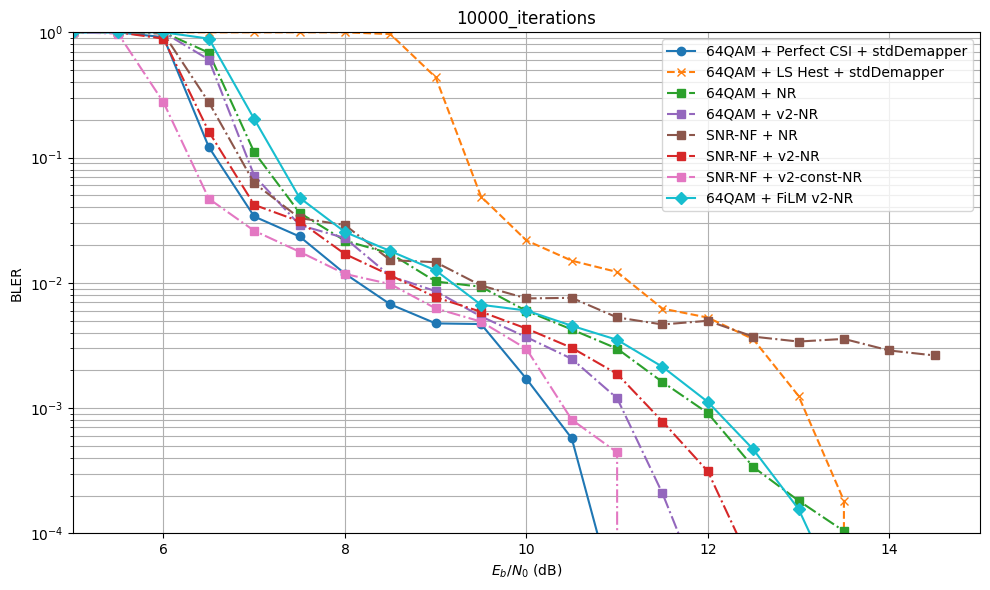

In [54]:
with open('E2E_baseline_result', 'rb') as file: 
        ebno_dbs, BLER_base, BER_base = pickle.load(file)
with open('10000_qam_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_qam, BER_qam = pickle.load(file)
with open('10000_qam_2stage_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_2stqam, BER_2stqam = pickle.load(file)
with open('10000_SNRNF_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_snrnf, BER_snrnf = pickle.load(file)
with open('10000_SNRNF_2stage_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_2stsnrnf, BER_2stsnrnf = pickle.load(file)
with open('10000_SNRNF_2stage_const_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_const, BER_const = pickle.load(file)

with open('FiLM/30000_qam_multi_mod_eval_results.pkl', 'rb') as file:
    ebno_dbs, BLER_film, BER_film = pickle.load(file)

plt.figure(figsize=(10,6))
# Baseline - Perfect CSI
plt.semilogy(ebno_dbs, BLER_base['baseline-perfect-csi'], 'o-', c=f'C0', label=f'64QAM + Perfect CSI + stdDemapper')
# Baseline - LS Estimation
plt.semilogy(ebno_dbs, BLER_base['baseline-ls-estimation'], 'x--', c=f'C1', label=f'64QAM + LS Hest + stdDemapper')
# Neural receiver
plt.semilogy(ebno_dbs, BLER_qam['neural-receiver-standard'], 's-.', c=f'C2', label=f'64QAM + NR')
plt.semilogy(ebno_dbs, BLER_2stqam['neural-receiver-standard'], 's-.', c=f'C4', label=f'64QAM + v2-NR')
plt.semilogy(ebno_dbs, BLER_snrnf['neural-receiver-standard'], 's-.', c=f'C5', label=f'SNR-NF + NR')
plt.semilogy(ebno_dbs, BLER_2stsnrnf['neural-receiver-standard'], 's-.', c=f'C3', label=f'SNR-NF + v2-NR')
plt.semilogy(ebno_dbs, BLER_const['neural-receiver-standard'], 's-.', c=f'C6', label=f'SNR-NF + v2-const-NR')

plt.semilogy(ebno_dbs, BLER_film['neural-film-6bps'], 'D-', c='C9', label='64QAM + FiLM v2-NR')

plt.title('10000_iterations')
plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BLER")
plt.grid(which="both")
plt.ylim((1e-4, 1.0))
plt.xlim((5, 15))
plt.legend()
plt.tight_layout()

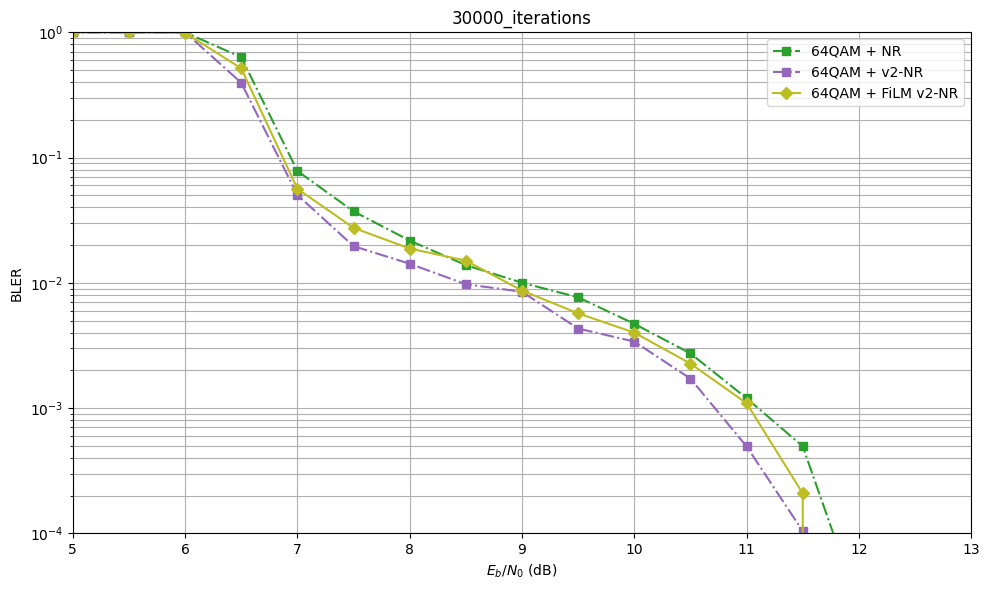

In [18]:
with open('E2E_baseline_result', 'rb') as file: 
        ebno_dbs, BLER_base, BER_base = pickle.load(file)
with open('30000_qam_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_qam, BER_qam = pickle.load(file)
with open('30000_qam_2stage_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_2stqam, BER_2stqam = pickle.load(file)
with open('30000_SNRNF_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_snrnf, BER_snrnf = pickle.load(file)
with open('30000_SNRNF_2stage_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_2stsnrnf, BER_2stsnrnf = pickle.load(file)
with open('30000_SNRNF_2stage_const_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_const, BER_const = pickle.load(file)
with open('30000_resNF_2stage_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_res, BER_res = pickle.load(file)

with open('iter_SNRNF_2stage_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_iter, BER_iter = pickle.load(file)
with open('iter_resNF_2stage_neural_receiver_model_result', 'rb') as file: 
        ebno_dbs, BLER_iterRES, BER_iterRES = pickle.load(file)

with open('FiLM/90000_qam_multi_mod_eval_results.pkl', 'rb') as file:
    ebno_dbs, BLER_film, BER_film = pickle.load(file)

plt.figure(figsize=(10,6))
# Baseline - Perfect CSI
# plt.semilogy(ebno_dbs, BLER_base['baseline-perfect-csi'], 'o-', c=f'C0', label=f'QAM + Perfect CSI + stdDemapper')
# Baseline - LS Estimation
# plt.semilogy(ebno_dbs, BLER_base['baseline-ls-estimation'], 'x--', c=f'C1', label=f'QAM + LS Hest + stdDemapper')
# Neural receiver
plt.semilogy(ebno_dbs, BLER_qam['neural-receiver-standard'], 's-.', c=f'C2', label=f'64QAM + NR')
plt.semilogy(ebno_dbs, BLER_2stqam['neural-receiver-standard'], 's-.', c=f'C4', label=f'64QAM + v2-NR')
# plt.semilogy(ebno_dbs, BLER_snrnf['neural-receiver-standard'], 's-.', c=f'C5', label=f'SNR-NF + NR')
# plt.semilogy(ebno_dbs, BLER_2stsnrnf['neural-receiver-standard'], 's-.', c=f'C3', label=f'SNR-NF + v2-NR')
# plt.semilogy(ebno_dbs, BLER_const['neural-receiver-standard'], 's-.', c=f'C9', label=f'SNR-NF + v2-const-NR')
# plt.semilogy(ebno_dbs, BLER_res['neural-receiver-standard'], 's-.', c=f'C6', label=f'Res-SNR-NF + v2-NR')
# plt.semilogy(ebno_dbs, BLER_iter['neural-receiver-standard'], 's-.', c=f'C7', label=f'Iter-SNR-NF + v2-NR')
# plt.semilogy(ebno_dbs, BLER_iterRES['neural-receiver-standard'], 's-.', c=f'C8', label=f'Iter-Res-SNR-NF + v2-NR')

plt.semilogy(ebno_dbs, BLER_film['neural-film-6bps'], 'D-', c='C8', label='64QAM + FiLM v2-NR')

plt.title('30000_iterations')
plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BLER")
plt.grid(which="both")
plt.ylim((1e-4, 1.0))
plt.xlim((5, 13))
plt.legend()
plt.tight_layout()

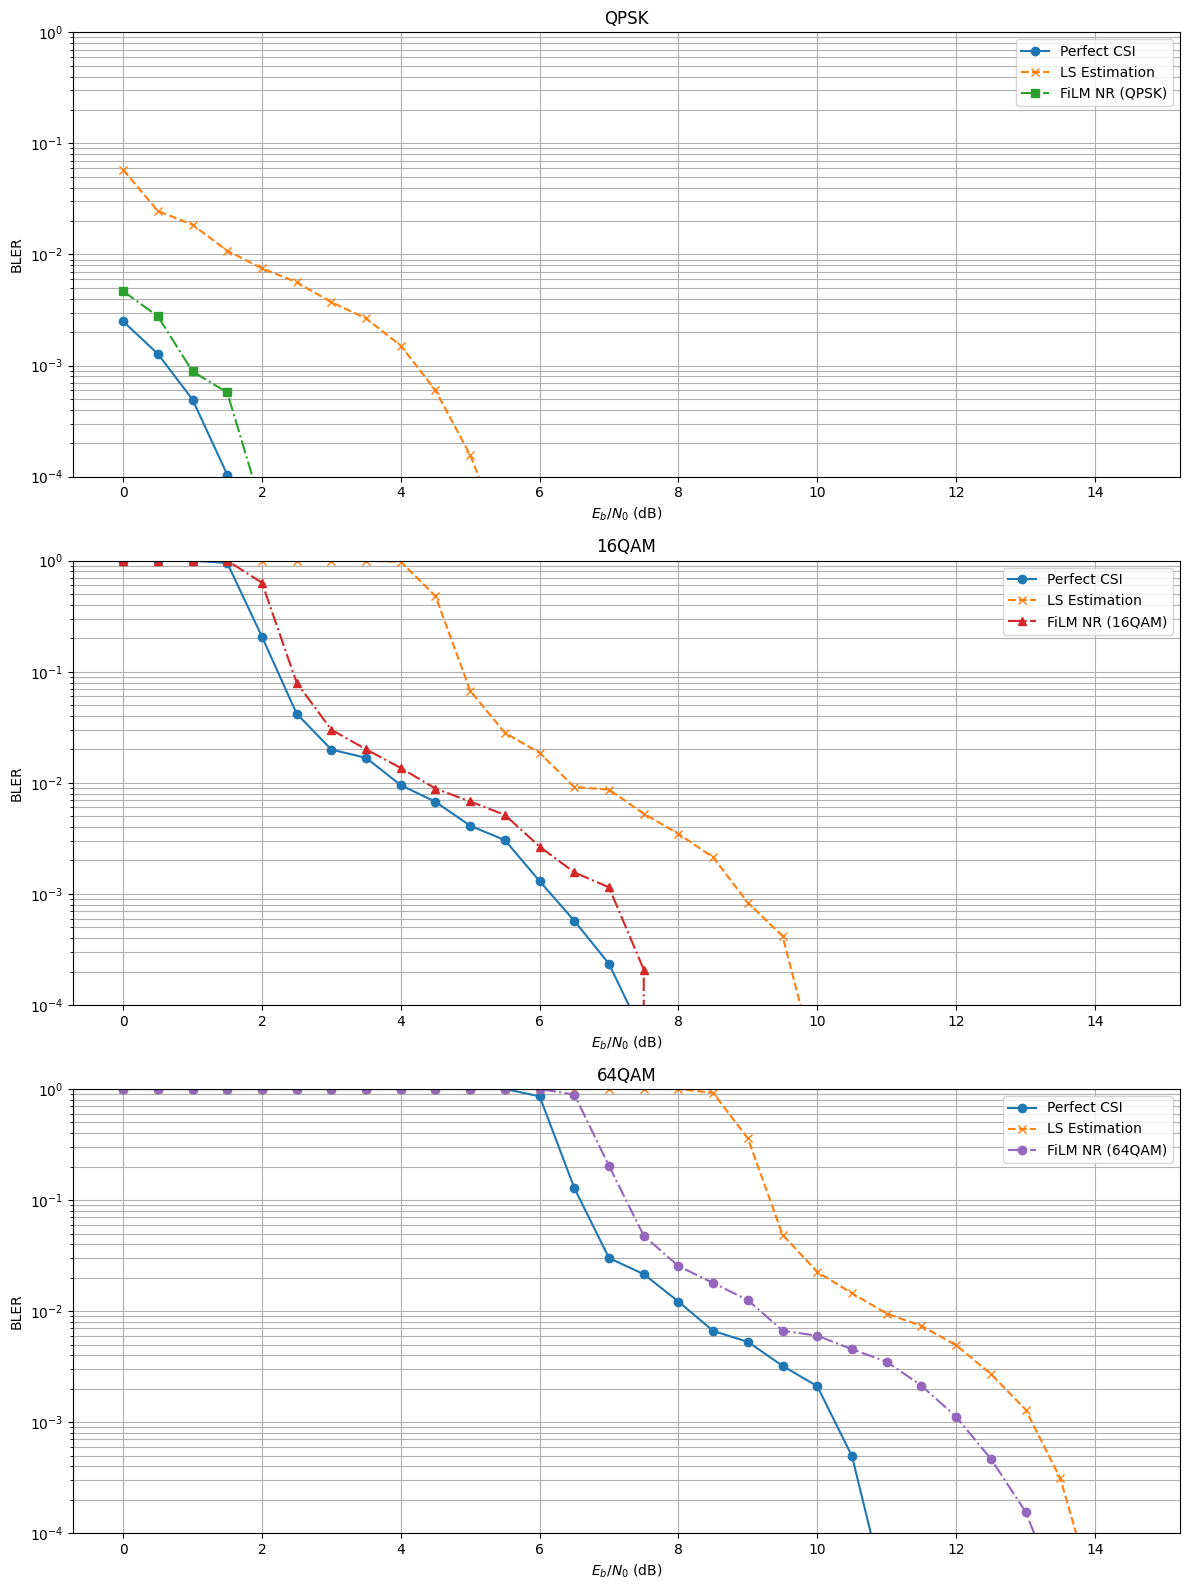

In [12]:
with open('FiLM/baseline_multi_mod_eval_results.pkl', 'rb') as file: 
    ebno_dbs, BLER_base, BER_base = pickle.load(file)
with open('FiLM/30000_qam_multi_mod_eval_results.pkl', 'rb') as file:
    ebno_dbs, BLER_film, BER_film = pickle.load(file)

MOD_LABELS = {2: 'QPSK', 4: '16QAM', 6: '64QAM'}
MOD_COLORS = {2: 'C2', 4: 'C3', 6: 'C4'}
MOD_MARKERS = {2: 's', 4: '^', 6: 'o'}

fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharey=True)

for ax, nbps in zip(axes, MOD_ORDERS):
    label = MOD_LABELS[nbps]
    
    # Classical baselines
    ax.semilogy(ebno_dbs, BLER_base[f'baseline-perfect-csi-{nbps}bps'],   'o-',  c='C0', label='Perfect CSI')
    ax.semilogy(ebno_dbs, BLER_base[f'baseline-ls-estimation-{nbps}bps'], 'x--', c='C1', label='LS Estimation')
    
    # FiLM multi-mod receiver
    ax.semilogy(ebno_dbs, BLER_film[f'neural-film-{nbps}bps'],
                f'{MOD_MARKERS[nbps]}-.', c=MOD_COLORS[nbps], label=f'FiLM NR ({label})')

    ax.set_title(f'{label}')
    ax.set_xlabel(r"$E_b/N_0$ (dB)")
    ax.set_ylabel("BLER")
    ax.grid(which="both")
    ax.set_ylim((1e-4, 1.0))
    ax.legend()

plt.tight_layout()
plt.show()

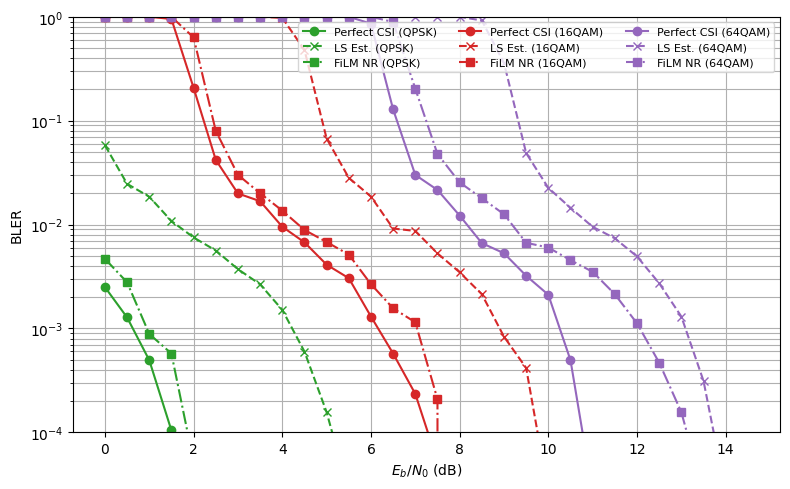

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

for nbps in MOD_ORDERS:
    label = MOD_LABELS[nbps]
    c = MOD_COLORS[nbps]
    ax.semilogy(ebno_dbs, BLER_base[f'baseline-perfect-csi-{nbps}bps'],   'o-',  c=c, label=f'Perfect CSI ({label})')
    ax.semilogy(ebno_dbs, BLER_base[f'baseline-ls-estimation-{nbps}bps'], 'x--', c=c, label=f'LS Est. ({label})')
    ax.semilogy(ebno_dbs, BLER_film[f'neural-film-{nbps}bps'],            's-.', c=c, label=f'FiLM NR ({label})')

ax.set_xlabel(r"$E_b/N_0$ (dB)")
ax.set_ylabel("BLER")
ax.grid(which="both")
ax.set_ylim((1e-4, 1.0))
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

Finally, we plots the BLERs

In [ ]:
with open('SISO_highco_coderate78', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)
with open('SISO_highco_uncoded', 'wb') as f:
    pickle.dump((ebno_dbs, BLER_uc, BER_uc), f)

In [ ]:
with open('SISO_coderate78', 'rb') as file: 
        ebno_dbs, BLER_s, BER_s = pickle.load(file)
with open('SISO_uncoded', 'rb') as file: 
        ebno_dbs, BLER_uc_s, BER_uc_s = pickle.load(file)
# with open('SIMO_coderate78', 'rb') as file: 
#         ebno_dbs, BLER_m, BER_m = pickle.load(file)
# with open('SIMO_uncoded', 'rb') as file: 
#         ebno_dbs, BLER_uc_m, BER_uc_m = pickle.load(file)
with open('SISO_highco_coderate78', 'rb') as file: 
        ebno_dbs, BLER_c, BER_c = pickle.load(file)
with open('SISO_highco_uncoded', 'rb') as file: 
        ebno_dbs, BLER_uc_c, BER_uc_c = pickle.load(file)

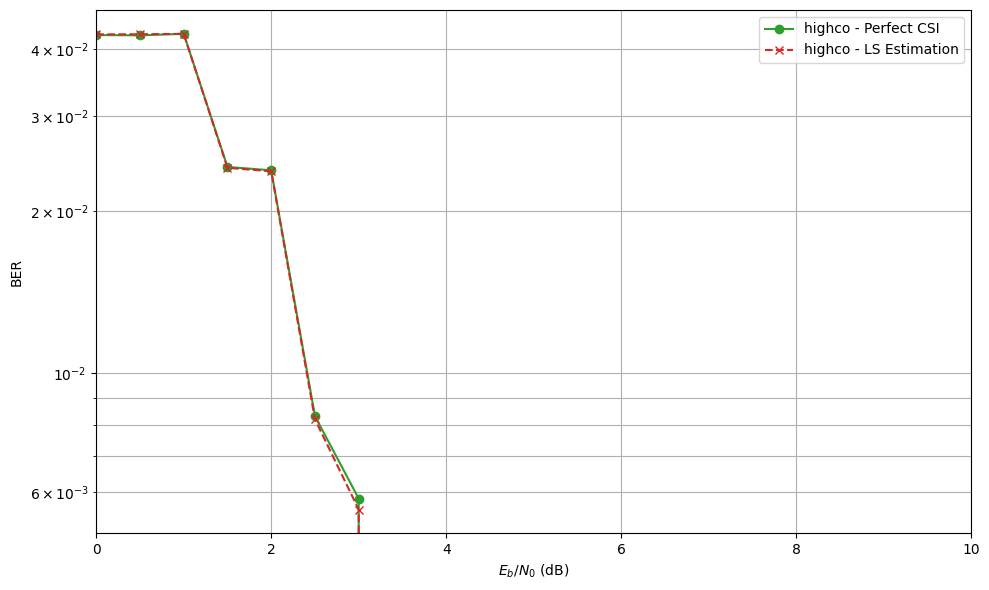

In [ ]:
plt.figure(figsize=(10,6))
# Baseline - Perfect CSI
# plt.semilogy(ebno_dbs, BER_s['baseline-perfect-csi'], 'o-', c=f'C0', label=f'coderate78 - Perfect CSI')
# # Baseline - LS Estimation
# plt.semilogy(ebno_dbs, BER_s['baseline-ls-estimation'], 'x--', c=f'C1', label=f'coderate78 - LS Estimation')

# plt.semilogy(ebno_dbs, BER_uc_s['baseline-perfect-csi'], 'o-', c=f'C4', label=f'uncoded - Perfect CSI')
# plt.semilogy(ebno_dbs, BER_uc_s['baseline-ls-estimation'], 'x--', c=f'C5', label=f'uncoded - LS Estimation')

plt.semilogy(ebno_dbs, BER_c['baseline-perfect-csi'], 'o-', c=f'C2', label=f'highco - Perfect CSI')
plt.semilogy(ebno_dbs, BER_c['baseline-ls-estimation'], 'x--', c=f'C3', label=f'highco - LS Estimation')
# plt.semilogy(ebno_dbs, BER_uc_c['baseline-perfect-csi'], 'o-', c=f'C6', label=f'uncoded-highco - Perfect CSI')
# plt.semilogy(ebno_dbs, BER_uc_c['baseline-ls-estimation'], 'x--', c=f'C7', label=f'uncoded-highco - LS Estimation')

# Neural receiver
# plt.semilogy(ebno_dbs, BLER['neural-receiver'], 's-.', c=f'C2', label=f'Neural receiver')
#
plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BER")
plt.grid(which="both")
# plt.ylim((1e-5, 1.0))
plt.xlim((0, 10))
plt.legend()
plt.tight_layout()

## References <a class="anchor" id="References"></a>

[1] M. Honkala, D. Korpi and J. M. J. Huttunen, "DeepRx: Fully Convolutional Deep Learning Receiver," in IEEE Transactions on Wireless Communications, vol. 20, no. 6, pp. 3925-3940, June 2021, doi: 10.1109/TWC.2021.3054520.

[2] F. Ait Aoudia and J. Hoydis, "End-to-end Learning for OFDM: From Neural Receivers to Pilotless Communication," in IEEE Transactions on Wireless Communications, doi: 10.1109/TWC.2021.3101364.

[3] Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun, "Deep Residual Learning for Image Recognition", Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 2016, pp. 770-778

[4] G. Böcherer, "Achievable Rates for Probabilistic Shaping", arXiv:1707.01134, 2017.